<a href="https://colab.research.google.com/github/fluschewisbest-collab/Colab-Project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import pandas as pd
url_clean = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Olympic%20Medals%20Dataset/olympics_clean.csv'
df_clean = pd.read_csv(url_clean)
display(df_clean.head())

,athlete_id,name,sex,age,height,weight,team,country_code,games_edition,year,season,city,sport,event,medal,is_medalist,is_art_competition,age_is_unusual
0,1,A Dijiang,Male,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,False,False,False
1,2,A Lamusi,Male,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,Male,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,False,False,False
3,4,Edgar Lindenau Aabye,Male,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,True,False,False
4,5,Christine Jacoba Aaftink,Female,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,False,False,False


**Cleaning and checking data integrety**

In [89]:
# Check df_clean info
print("--- df_clean.info() ---")
df_clean.info()

--- df_clean.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269731 entries, 0 to 269730
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   athlete_id          269731 non-null  int64  
 1   name                269731 non-null  object 
 2   sex                 269731 non-null  object 
 3   age                 260416 non-null  float64
 4   height              210917 non-null  float64
 5   weight              208204 non-null  float64
 6   team                269731 non-null  object 
 7   country_code        269731 non-null  object 
 8   games_edition       269731 non-null  object 
 9   year                269731 non-null  int64  
 10  season              269731 non-null  object 
 11  city                269731 non-null  object 
 12  sport               269731 non-null  object 
 13  event               269731 non-null  object 
 14  medal               39772 non-null   object 
 15  is_medalis

In [90]:
# Missing values in df_clean
print("\n--- Missing values in df_clean ---")
missing_clean = df_clean.isnull().sum()
missing_clean_percent = (missing_clean / len(df_clean)) * 100
missing_df_clean = pd.DataFrame({'Total Missing': missing_clean, 'Percentage (%)': missing_clean_percent})
display(missing_df_clean[missing_df_clean['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False))


--- Missing values in df_clean ---


,Total Missing,Percentage (%)
medal,229959,85.254939
weight,61527,22.810504
height,58814,21.804687
age,9315,3.453441


In [91]:
# Check for duplicate rows in df_clean
print(f"Number of duplicate rows in df_clean: {df_clean.duplicated().sum()}")

Number of duplicate rows in df_clean: 0


In [92]:
# Check unique values for 'sex' in df_clean
print("\n--- df_clean['sex'].value_counts() ---")
display(df_clean['sex'].value_counts())


--- df_clean['sex'].value_counts() ---


,count
sex,
Male,195353
Female,74378


In [93]:
# Check unique values for 'medal' in df_clean
print("\n--- df_clean['medal'].value_counts() ---")
display(df_clean['medal'].value_counts(dropna=False)) # Include NaN counts


--- df_clean['medal'].value_counts() ---


,count
medal,
NaN,229959
Gold,13369
Bronze,13295
Silver,13108


In [94]:
print(f"Total number of rows in df_clean: {len(df_clean)}")

Total number of rows in df_clean: 269731


**Question** **1** - Do short or tall atheltes perform better over long distance races (10k)?

**Summary of code**

### Analyzing Medal Performance Across All Distance Running Events by Height

To broaden our analysis, let's look at medal performance across several common distance running events in Athletics and see how different height categories fare.

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define common distance running events, excluding 'walk', 'Steeplechase', and 'Team'
distance_events = [
    '800 metres',
    '1,500 metres',
    '3,000 metres',
    '5,000 metres',
    '10,000 metres',
    'Marathon'
]

# Filter for distance events in Athletics with valid height and medal data
# and explicitly exclude 'Walk', 'Steeplechase', and 'Team' events
df_distance_events = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team', na=False)) &
    (df_clean['height'].notna()) &
    (df_clean['medal'].notna())
].copy()

# Create height bins using the same quartile approach
df_distance_events['height_category'] = pd.qcut(
    df_distance_events['height'],
    q=4,
    labels=['Short (Q1)', 'Medium-Short (Q2)', 'Medium-Tall (Q3)', 'Tall (Q4)'],
    duplicates='drop'
)

# Count medals per height category for each event
medals_by_height_event = df_distance_events.groupby(['event', 'height_category'], observed=False)['medal'].count().reset_index()
medals_by_height_event.rename(columns={'medal': 'num_medals'}, inplace=True)

<Figure size 1500x800 with 0 Axes>

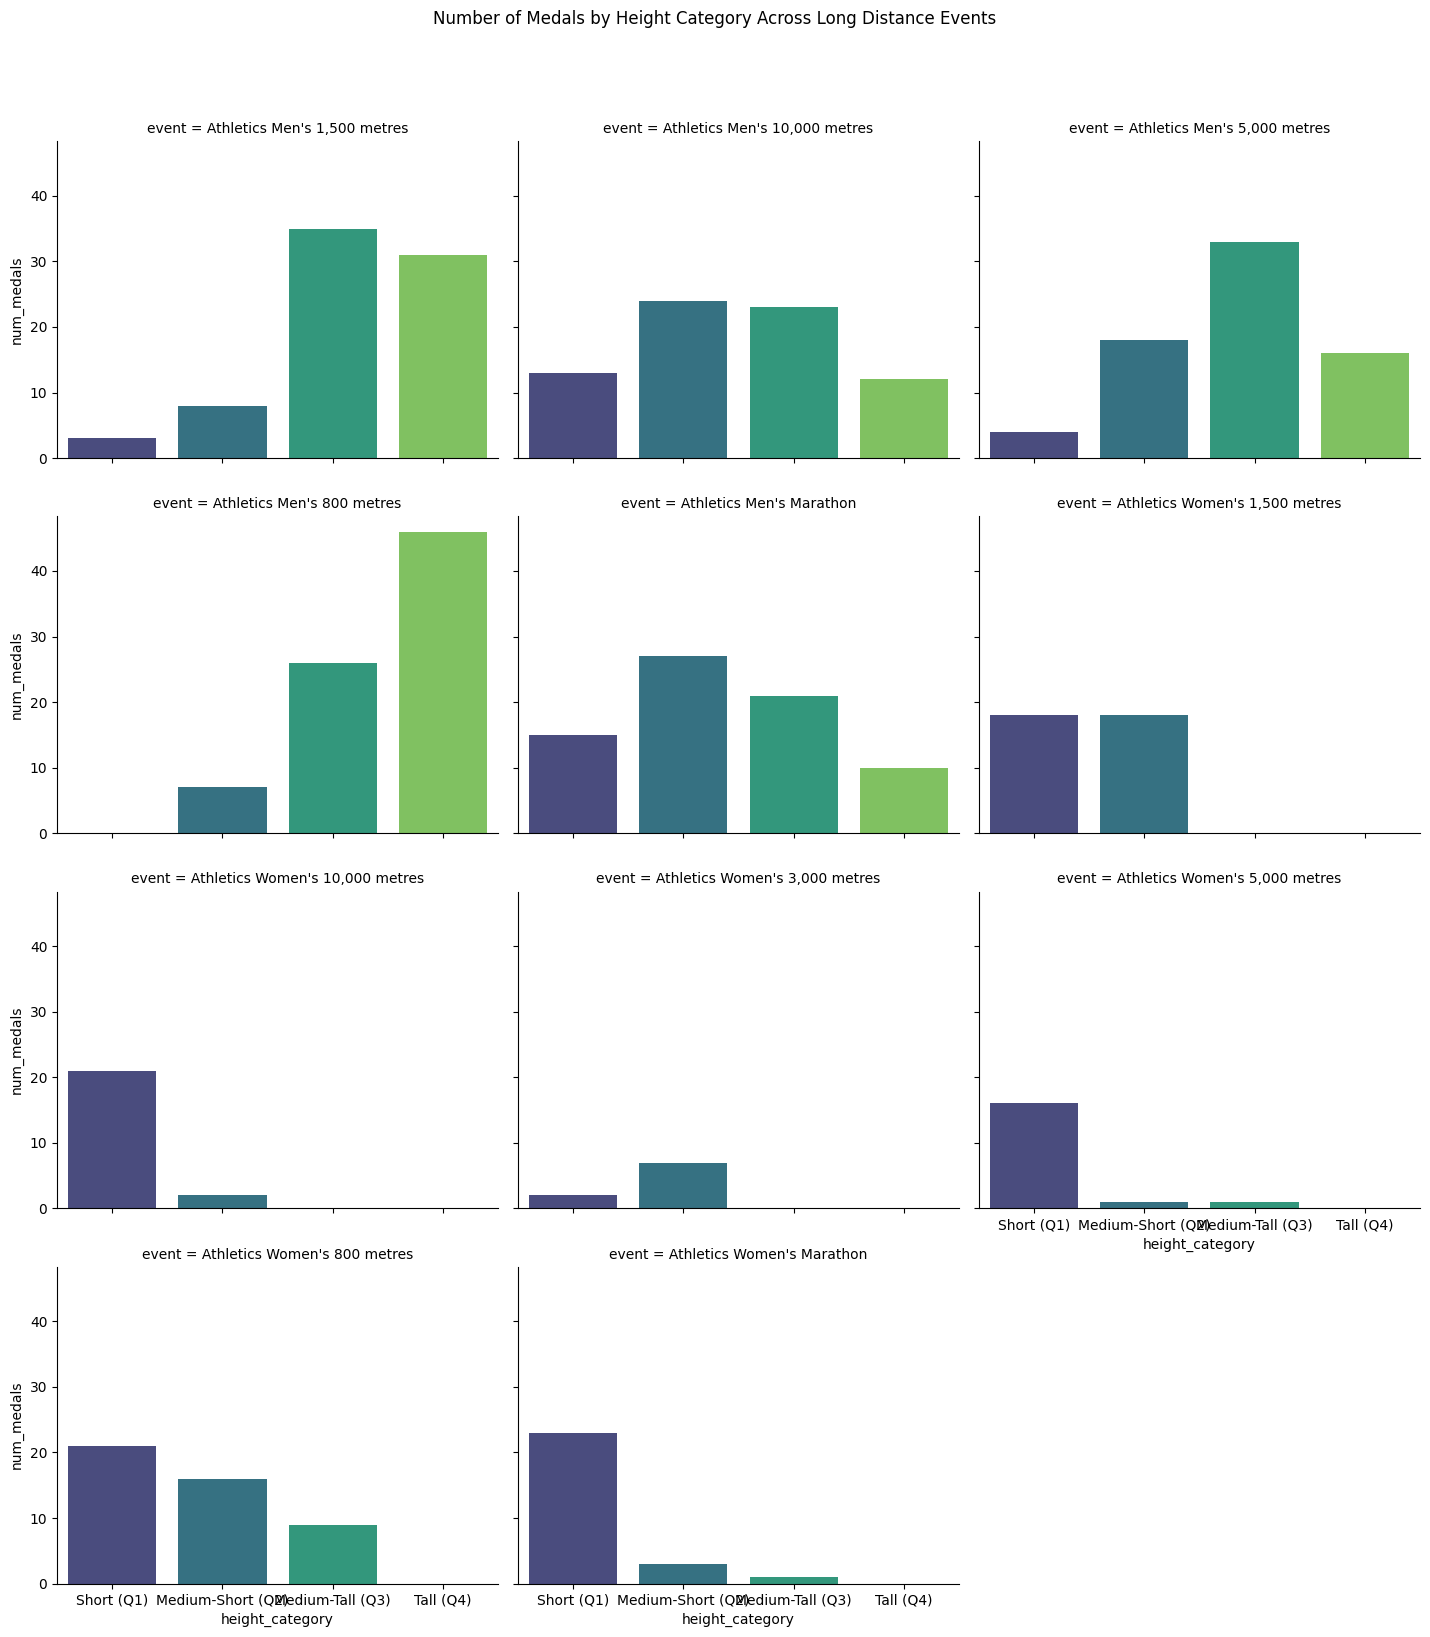

In [96]:
plt.figure(figsize=(15, 8))
sns.catplot(
    data=medals_by_height_event,
    x='height_category',
    y='num_medals',
    kind='bar',
    palette='viridis',
    hue='height_category', # Explicitly assign hue to remove Futurearning
    col='event', # Create separate plots for each event
    col_wrap=3, # Wrap columns after 3 plots
    height=4, aspect=1.2, # Adjust figure size
    sharey=True, # Share the y-axis across all subplots
    legend=False # Remove the legend (as hue is now explicitly set, this hides the default legend)
)

plt.suptitle('Number of Medals by Height Category Across Long Distance Events', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

### Analyzing Medal Performance Across Short-Distance Running Events by Height

In [97]:
# Define common short-distance running events (under 800 metres)
short_distance_events = [
    '100 metres',
    '200 metres',
    '400 metres'
]

# Filter for short-distance events in Athletics with valid height and medal data
# and explicitly exclude 'Walk', 'Steeplechase', 'Team', 'Relay', and 'Hurdles' events
df_short_distance_events = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(short_distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team|Relay|Hurdles', na=False)) &
    (df_clean['height'].notna()) &
    (df_clean['medal'].notna())
].copy()

# Create height bins using the same quartile approach as before
df_short_distance_events['height_category'] = pd.qcut(
    df_short_distance_events['height'],
    q=4,
    labels=['Short (Q1)', 'Medium-Short (Q2)', 'Medium-Tall (Q3)', 'Tall (Q4)'],
    duplicates='drop'
)

# Count medals per height category for each event
medals_by_height_short_event = df_short_distance_events.groupby(['event', 'height_category'], observed=False)['medal'].count().reset_index()
medals_by_height_short_event.rename(columns={'medal': 'num_medals'}, inplace=True)

<Figure size 1500x800 with 0 Axes>

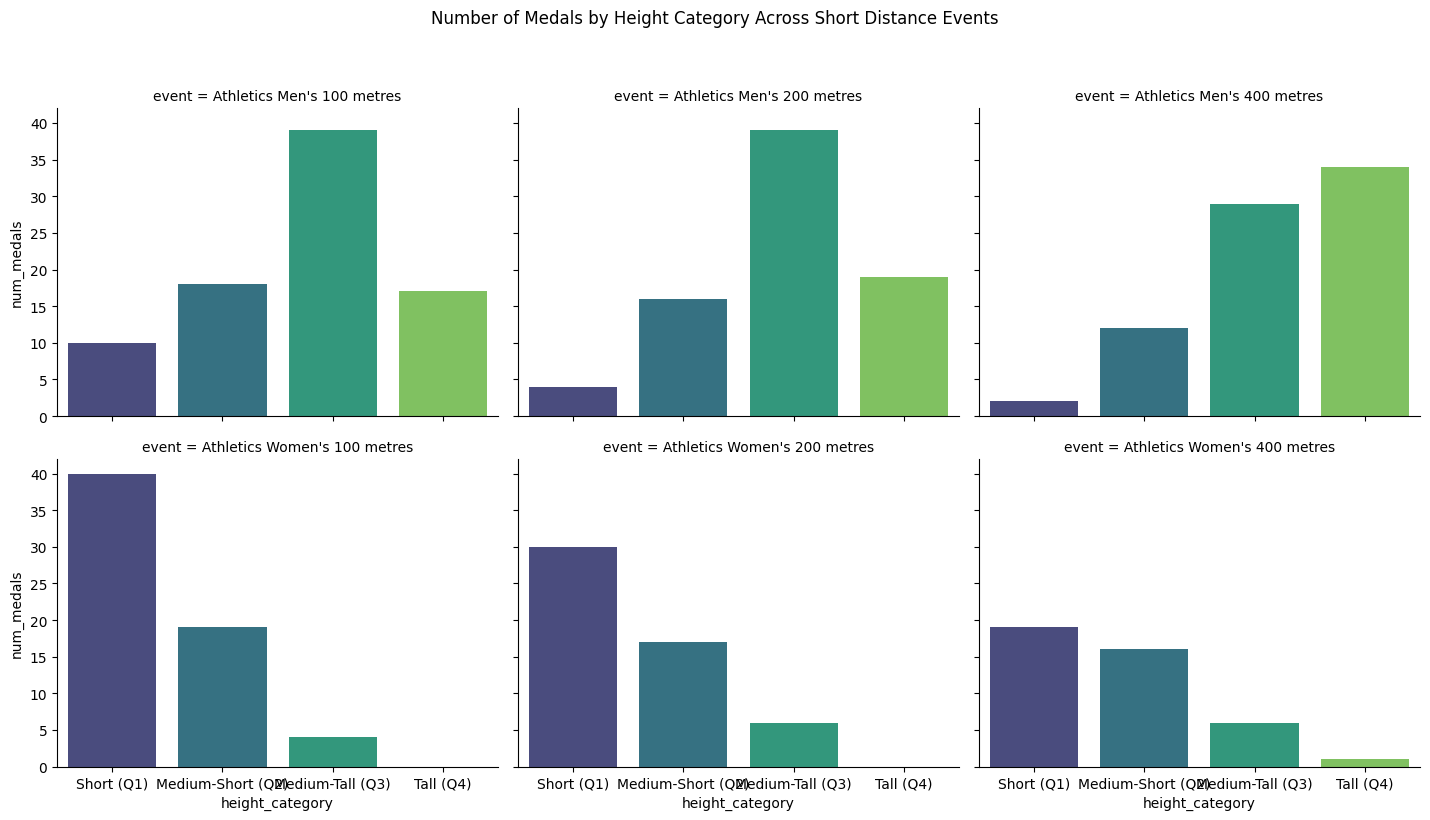

In [98]:
plt.figure(figsize=(15, 8))
sns.catplot(
    data=medals_by_height_short_event,
    x='height_category',
    y='num_medals',
    kind='bar',
    palette='viridis',
    hue='height_category',
    col='event',
    col_wrap=3,
    height=4, aspect=1.2,
    sharey=True,
    legend=False
)

plt.suptitle('Number of Medals by Height Category Across Short Distance Events', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

I saw tall men dominate their events for the most part but short women dominate theirs. To potentially gain more insight I made code to show a scatter plot to help visual better



```
# This is formatted as code
```

### Average Height of Medalists in Short-Distance Events by Gender

In [99]:
# Calculate average height for male medalists in short-distance events
average_height_men_short_distance = df_short_distance_events[df_short_distance_events['sex'] == 'Male']['height'].mean()

# Calculate average height for female medalists in short-distance events
average_height_women_short_distance = df_short_distance_events[df_short_distance_events['sex'] == 'Female']['height'].mean()

print(f"Average height of Male Medalists in Short-Distance Events: {average_height_men_short_distance:.2f} cm")
print(f"Average height of Female Medalists in Short-Distance Events: {average_height_women_short_distance:.2f} cm")

Average height of Male Medalists in Short-Distance Events: 180.86 cm
Average height of Female Medalists in Short-Distance Events: 170.34 cm


### Detailed Height Distribution Plots by Event and Gender (Medalists Highlighted)

Generating plots for Male Competitors...


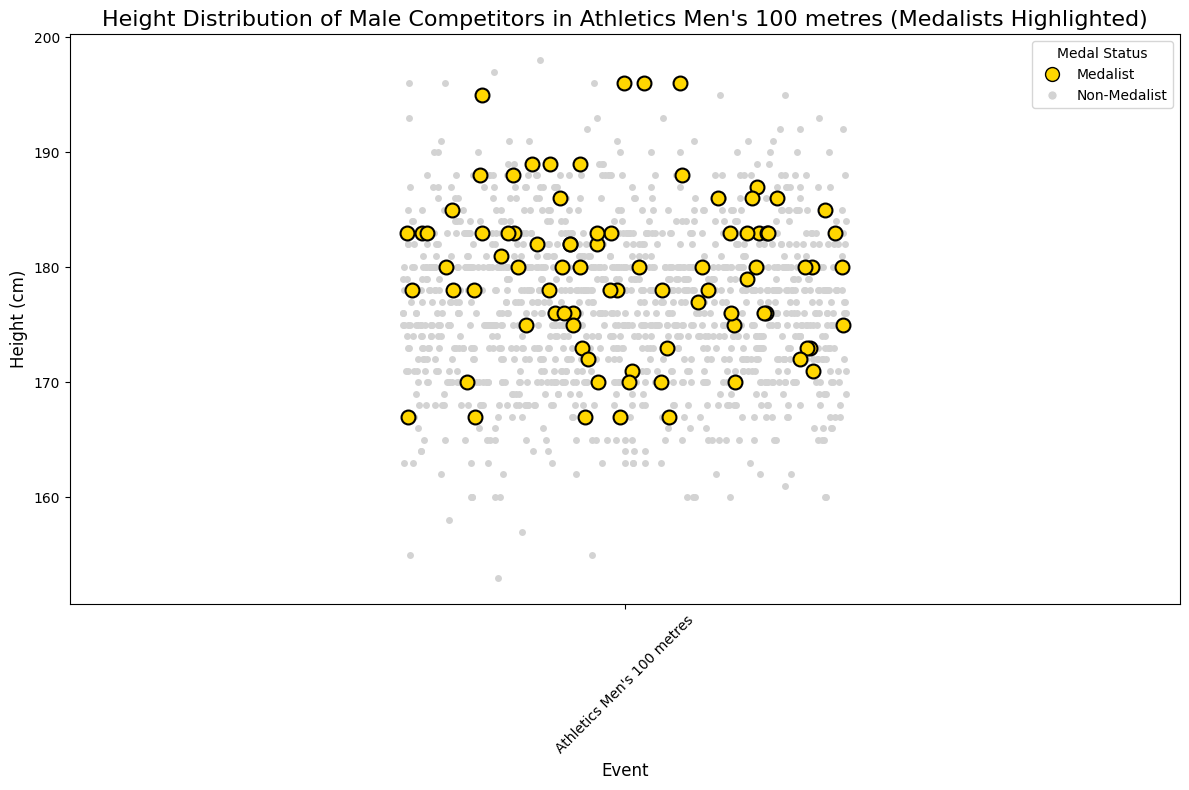

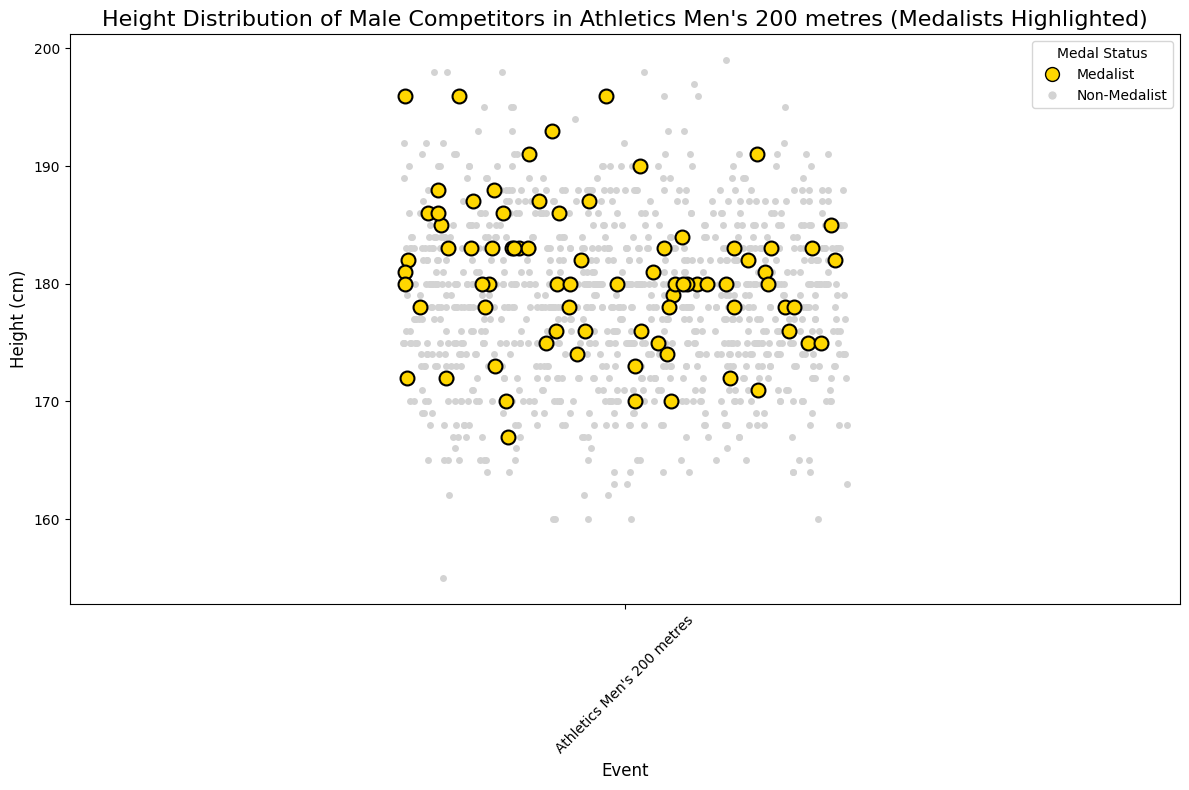

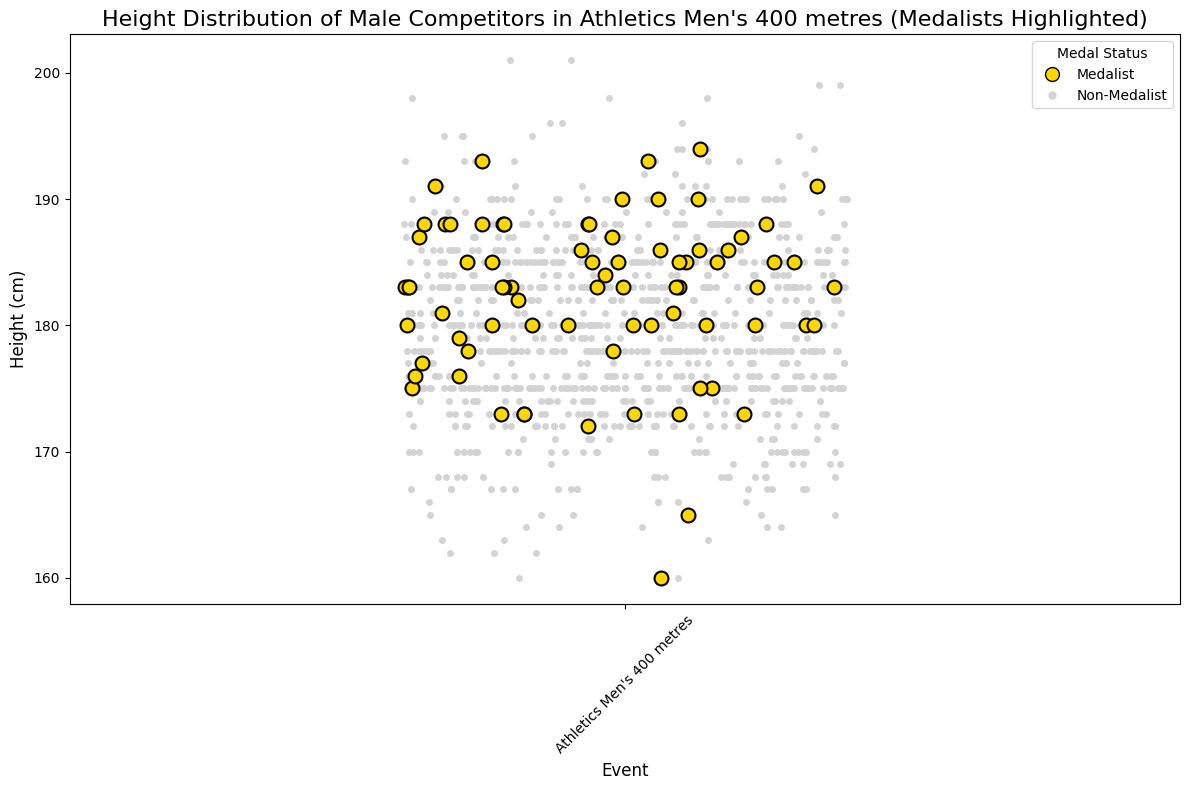

Generating plots for Female Competitors...


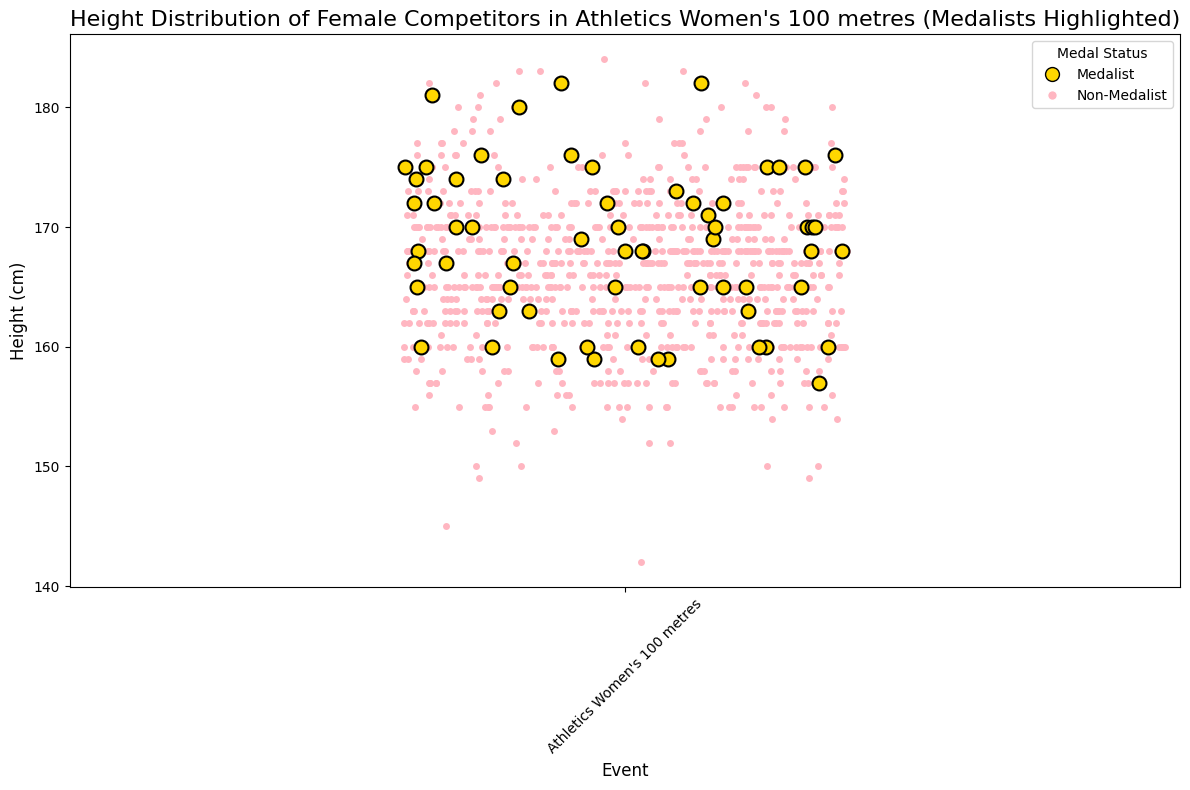

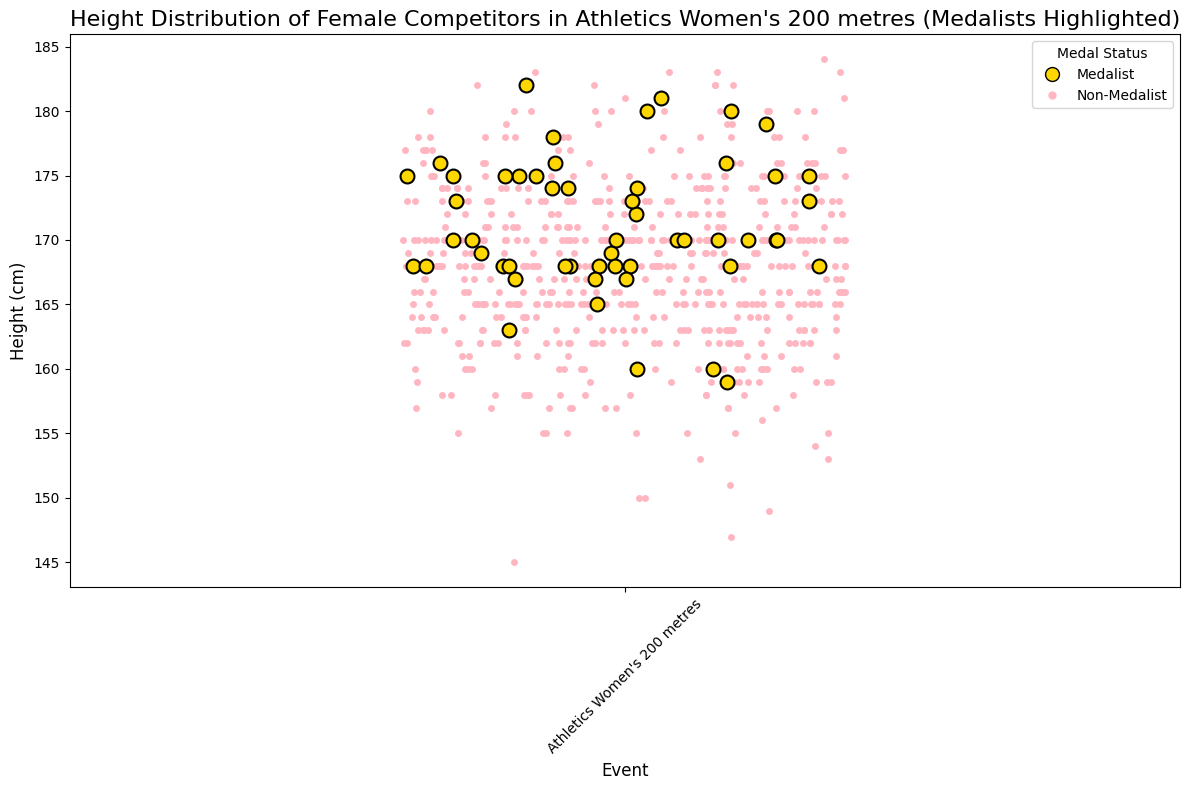

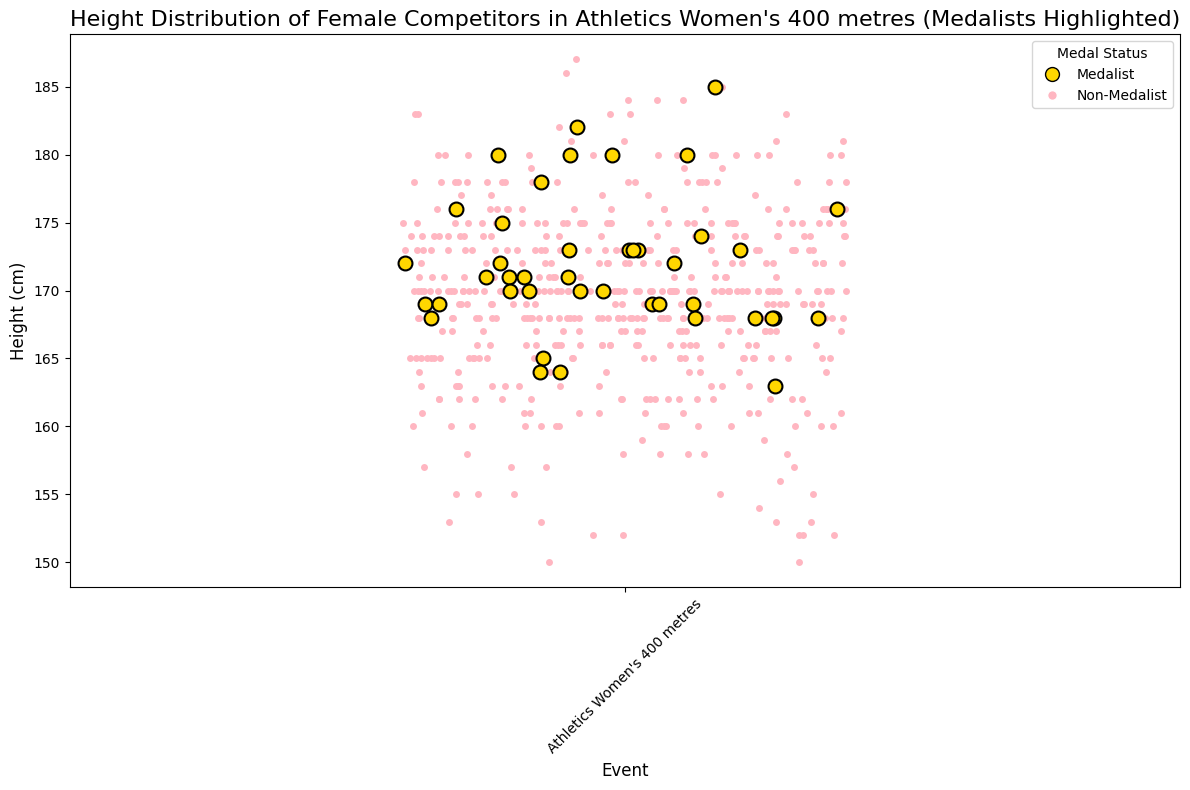


--- Corrected check for missing height data among medalists in observed events ---
Total medalists in short-distance events: 414
Number of medalists in short-distance events with missing height: 17
Percentage of medalists in short-distance events with missing height: 4.11%

Total medalists in long-distance events: 567
Number of medalists in long-distance events with missing height: 36
Percentage of medalists in long-distance events with missing height: 6.35%


In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Ensure 'is_medalist' column exists in df_all_short_distance_competitors
# If it doesn't, create it based on whether 'medal' is non-null
if 'is_medalist' not in df_all_short_distance_competitors.columns:
    df_all_short_distance_competitors['is_medalist'] = df_all_short_distance_competitors['medal'].notna()

# --- Plots for Male Competitors ---
print("Generating plots for Male Competitors...")
for event_name in sorted(df_all_short_distance_competitors['event'].unique()):
    if "Men's" in event_name: # Filter only male events
        df_plot_event = df_all_short_distance_competitors[
            (df_all_short_distance_competitors['sex'] == 'Male') &
            (df_all_short_distance_competitors['event'] == event_name)
        ].copy()

        if not df_plot_event.empty:
            fig, ax = plt.subplots(figsize=(12, 8)) # Make individual plots large

            df_medalists = df_plot_event[df_plot_event['is_medalist'] == True]
            df_non_medalists = df_plot_event[df_plot_event['is_medalist'] == False]

            # Plot non-medalists first (smaller, lightgrey)
            sns.stripplot(
                data=df_non_medalists,
                x='event',
                y='height',
                color='lightgrey',
                jitter=0.2,
                size=5, # Smaller size for non-medalists
                ax=ax
            )

            # Plot medalists on top (larger, gold, black edge)
            sns.stripplot(
                data=df_medalists,
                x='event',
                y='height',
                color='gold',
                jitter=0.2,
                size=10, # Larger size for medalists
                edgecolor='black', # Black edge for medalists
                linewidth=1.5, # Thicker edge
                ax=ax
            )

            ax.set_title(f'Height Distribution of Male Competitors in {event_name} (Medalists Highlighted)', fontsize=16)
            ax.set_xlabel('Event', fontsize=12)
            ax.set_ylabel('Height (cm)', fontsize=12)
            ax.tick_params(axis='x', rotation=45)

            # Create a custom legend for the plot
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', label='Medalist',
                       markerfacecolor='gold', markeredgecolor='black', markersize=10),
                Line2D([0], [0], marker='o', color='w', label='Non-Medalist',
                       markerfacecolor='lightgrey', markersize=7)
            ]
            ax.legend(handles=legend_elements, title='Medal Status', loc='upper right')

            plt.tight_layout()
            plt.show()

# --- Plots for Female Competitors ---
print("Generating plots for Female Competitors...")
for event_name in sorted(df_all_short_distance_competitors['event'].unique()):
    if "Women's" in event_name: # Filter only female events
        df_plot_event = df_all_short_distance_competitors[
            (df_all_short_distance_competitors['sex'] == 'Female') &
            (df_all_short_distance_competitors['event'] == event_name)
        ].copy()

        if not df_plot_event.empty:
            fig, ax = plt.subplots(figsize=(12, 8)) # Make individual plots large

            df_medalists = df_plot_event[df_plot_event['is_medalist'] == True]
            df_non_medalists = df_plot_event[df_plot_event['is_medalist'] == False]

            # Plot non-medalists first (smaller, lightpink)
            sns.stripplot(
                data=df_non_medalists,
                x='event',
                y='height',
                color='lightpink',
                jitter=0.2,
                size=5,
                ax=ax
            )

            # Plot medalists on top (larger, gold, black edge)
            sns.stripplot(
                data=df_medalists,
                x='event',
                y='height',
                color='gold',
                jitter=0.2,
                size=10,
                edgecolor='black',
                linewidth=1.5,
                ax=ax
            )

            ax.set_title(f'Height Distribution of Female Competitors in {event_name} (Medalists Highlighted)', fontsize=16)
            ax.set_xlabel('Event', fontsize=12)
            ax.set_ylabel('Height (cm)', fontsize=12)
            ax.tick_params(axis='x', rotation=45)

            # Create a custom legend for the plot
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', label='Medalist',
                       markerfacecolor='gold', markeredgecolor='black', markersize=10),
                Line2D([0], [0], marker='o', color='w', label='Non-Medalist',
                       markerfacecolor='lightpink', markersize=7)
            ]
            ax.legend(handles=legend_elements, title='Medal Status', loc='upper right')

            plt.tight_layout()
            plt.show()

# --- Corrected Check for missing height in medalists for observed events ---
print("\n--- Corrected check for missing height data among medalists in observed events ---")

# Define common short-distance running events (under 800 metres) from earlier cell
short_distance_events = [
    '100 metres',
    '200 metres',
    '400 metres'
]

# Define common distance running events from earlier cell
distance_events = [
    '800 metres',
    '1,500 metres',
    '3,000 metres',
    '5,000 metres',
    '10,000 metres',
    'Marathon'
]

# Filter df_clean for short-distance events and medalists
df_short_distance_medalists = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(short_distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team|Relay|Hurdles', na=False)) &
    (df_clean['medal'].notna()) # Filter for medalists
]

# Total medalists in short-distance events
total_medalists_short_distance = df_short_distance_medalists.shape[0]

# Missing height among short-distance medalists
missing_height_short_distance = df_short_distance_medalists['height'].isna().sum()

# Percentage missing
percentage_missing_short_distance = (missing_height_short_distance / total_medalists_short_distance) * 100 if total_medalists_short_distance > 0 else 0

print(f"Total medalists in short-distance events: {total_medalists_short_distance}")
print(f"Number of medalists in short-distance events with missing height: {missing_height_short_distance}")
print(f"Percentage of medalists in short-distance events with missing height: {percentage_missing_short_distance:.2f}%")

# Filter df_clean for long-distance events and medalists
df_long_distance_medalists = df_clean[
    (df_clean['sport'] == 'Athletics') &
    (df_clean['event'].str.contains('|'.join(distance_events), na=False)) &
    (~df_clean['event'].str.contains('Walk|Steeplechase|Team', na=False)) &
    (df_clean['medal'].notna()) # Filter for medalists
]

# Total medalists in long-distance events
total_medalists_long_distance = df_long_distance_medalists.shape[0]

# Missing height among long-distance medalists
missing_height_long_distance = df_long_distance_medalists['height'].isna().sum()

# Percentage missing
percentage_missing_long_distance = (missing_height_long_distance / total_medalists_long_distance) * 100 if total_medalists_long_distance > 0 else 0

print(f"\nTotal medalists in long-distance events: {total_medalists_long_distance}")
print(f"Number of medalists in long-distance events with missing height: {missing_height_long_distance}")
print(f"Percentage of medalists in long-distance events with missing height: {percentage_missing_long_distance:.2f}%")


**Next I knew from my data cleaning some entries had missing heights so I decided to test this on my results - I updated the code to show only those with height values. I also added code to show which have missing values and what percent they make up(shown at the bottom) **